In [45]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [6]:
df = pd.read_csv("advertising.csv.csv")
df

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [8]:
df.isnull().sum()

TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

In [9]:
df.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.056648,0.901208
Radio,0.054809,1.000000,0.354104,0.349631
Newspaper,0.056648,0.354104,1.000000,0.157960
Sales,0.901208,0.349631,0.157960,1.000000


### VISUALIZATION

As we can see using the correlation function we can see that the TV marketing cost is the mostly positively correlated to the Sales . So to Visualize this we will use the scatter function from the plt library and we will also use the pairplot function from the seaborn library to check visually that the other features arent very well related

Text(0, 0.5, 'Sales')

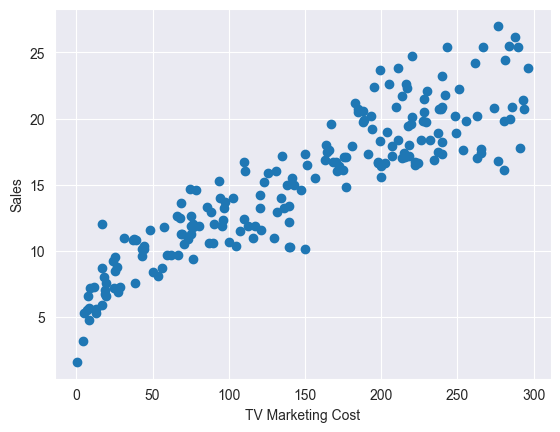

In [12]:
plt.scatter(y=df["Sales"],x=df["TV"])
plt.xlabel("TV Marketing Cost")
plt.ylabel("Sales")

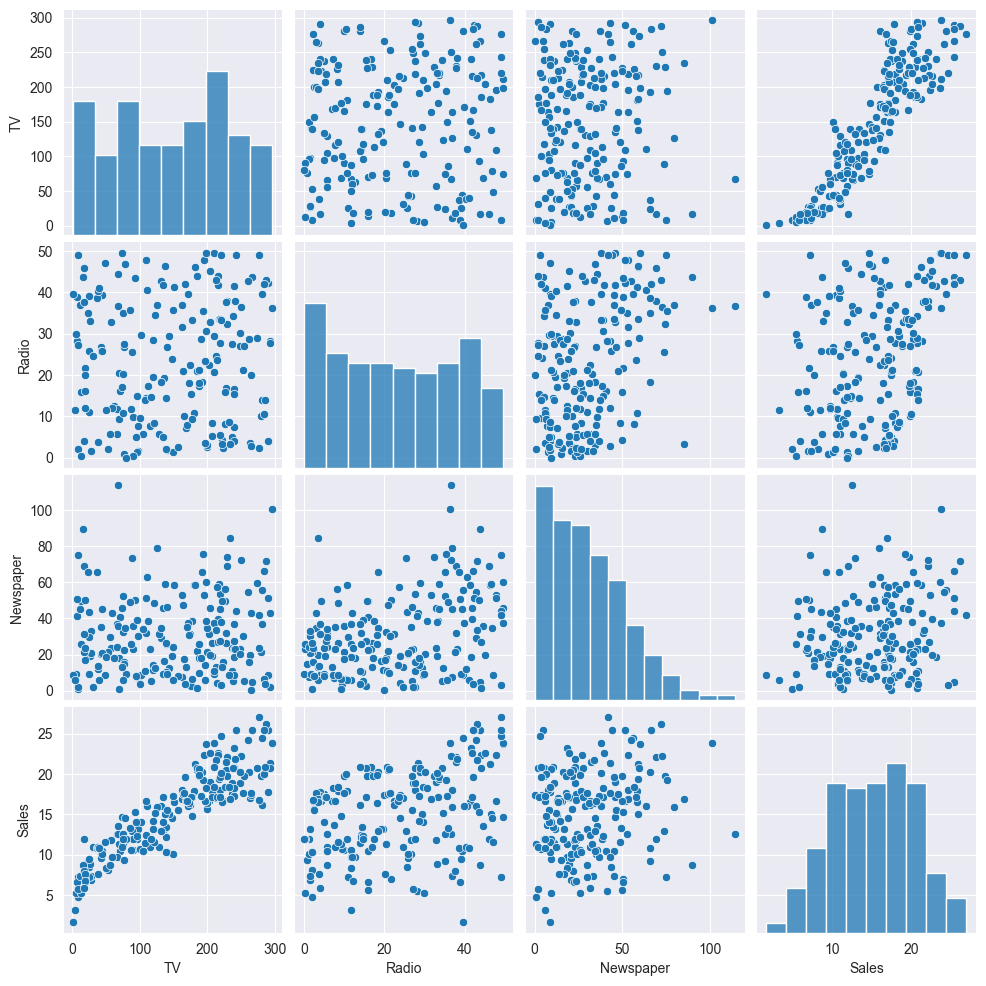

In [13]:
sns.pairplot(df)

As we have visually also checked the correlation we will now select the TV marketing as our only feature and the sales as our label

### Model Training

As we can see visually the TV marketing and the Sales are linearly related we will use a Simple Linear Regression model to predict our sales . We will be using the LinearRegression Model from the scikit learn Library .

### Splitting data

Before training the model we will first split the dataset into training and testing dataset . We will split the dataset into 8:2 ratio and we will use the random state parameter also

In [14]:
X = df.drop(columns=["Sales","Newspaper","Radio"])
y = df["Sales"]

In [15]:
print(X.shape)
print(y.shape)

(200, 1)
(200,)


In [16]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [17]:
linear_reg = LinearRegression()
linear_reg.fit(X_train,y_train)

LinearRegression()

In [18]:
y_pred = linear_reg.predict(X_test)

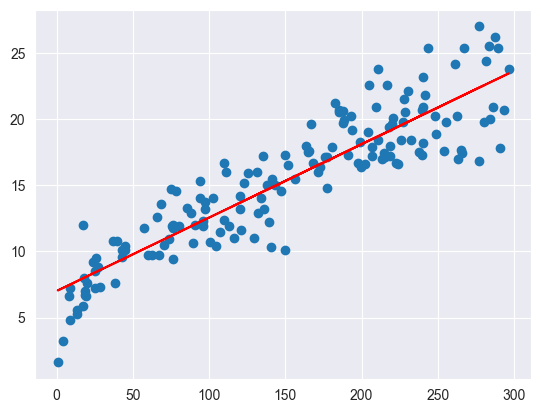

In [21]:
plt.scatter(X_train,y_train)
plt.plot(X_train,linear_reg.predict(X_train),color='red')

In [23]:
print(linear_reg.coef_,linear_reg.intercept_)

[0.05548294] 7.00710842824185


In [24]:
mse = mean_squared_error(y_test,y_pred)
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
adjusted_r2 = 1 - (1-r2)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)
print(mse,mae,rmse,r2,adjusted_r2)

6.101072906773963 1.9502948931650088 2.470035001123256 0.802561303423698 0.7973655482506374


### EVALUATION METRIC

We used R^2 , RMSE and other methods to check the accuracy and errors of the model . We got R^2 as 0.803 which is not bad but not good also . To increase the R^2 value what we can do is refer to the scatter plot earlier . In the above plot we can see some outliers . Removing these outliers will increase our R^2 value

We can use IQR ( Inter Quartile Range )  to remove these outliers .

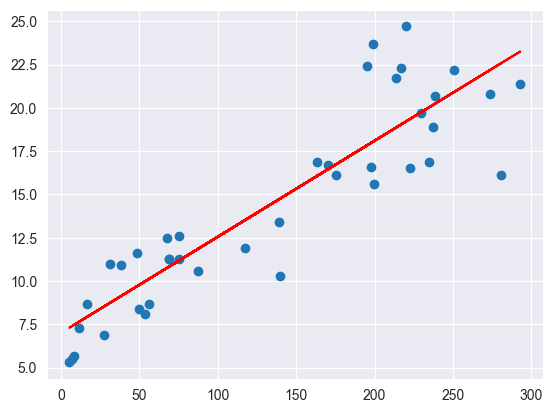

In [33]:
plt.scatter(X_test, y_test)
plt.plot(X_test,7.00710842824185  + 0.05548294 * X_test, 'r')
plt.show()

# MULTI FEATURE LINEAR REGRESSION

In [36]:
df_mult = pd.read_csv("Real estate.csv")
df_mult

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1
...,...,...,...,...,...,...,...,...
409,410,2013.000,13.7,4082.01500,0,24.94155,121.50381,15.4
410,411,2012.667,5.6,90.45606,9,24.97433,121.54310,50.0
411,412,2013.250,18.8,390.96960,7,24.97923,121.53986,40.6
412,413,2013.000,8.1,104.81010,5,24.96674,121.54067,52.5


In [38]:
df_mult.isnull().sum()

No                                        0
X1 transaction date                       0
X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [39]:
X = df_mult.drop(columns=["Y house price of unit area"])
y = df_mult["Y house price of unit area"]


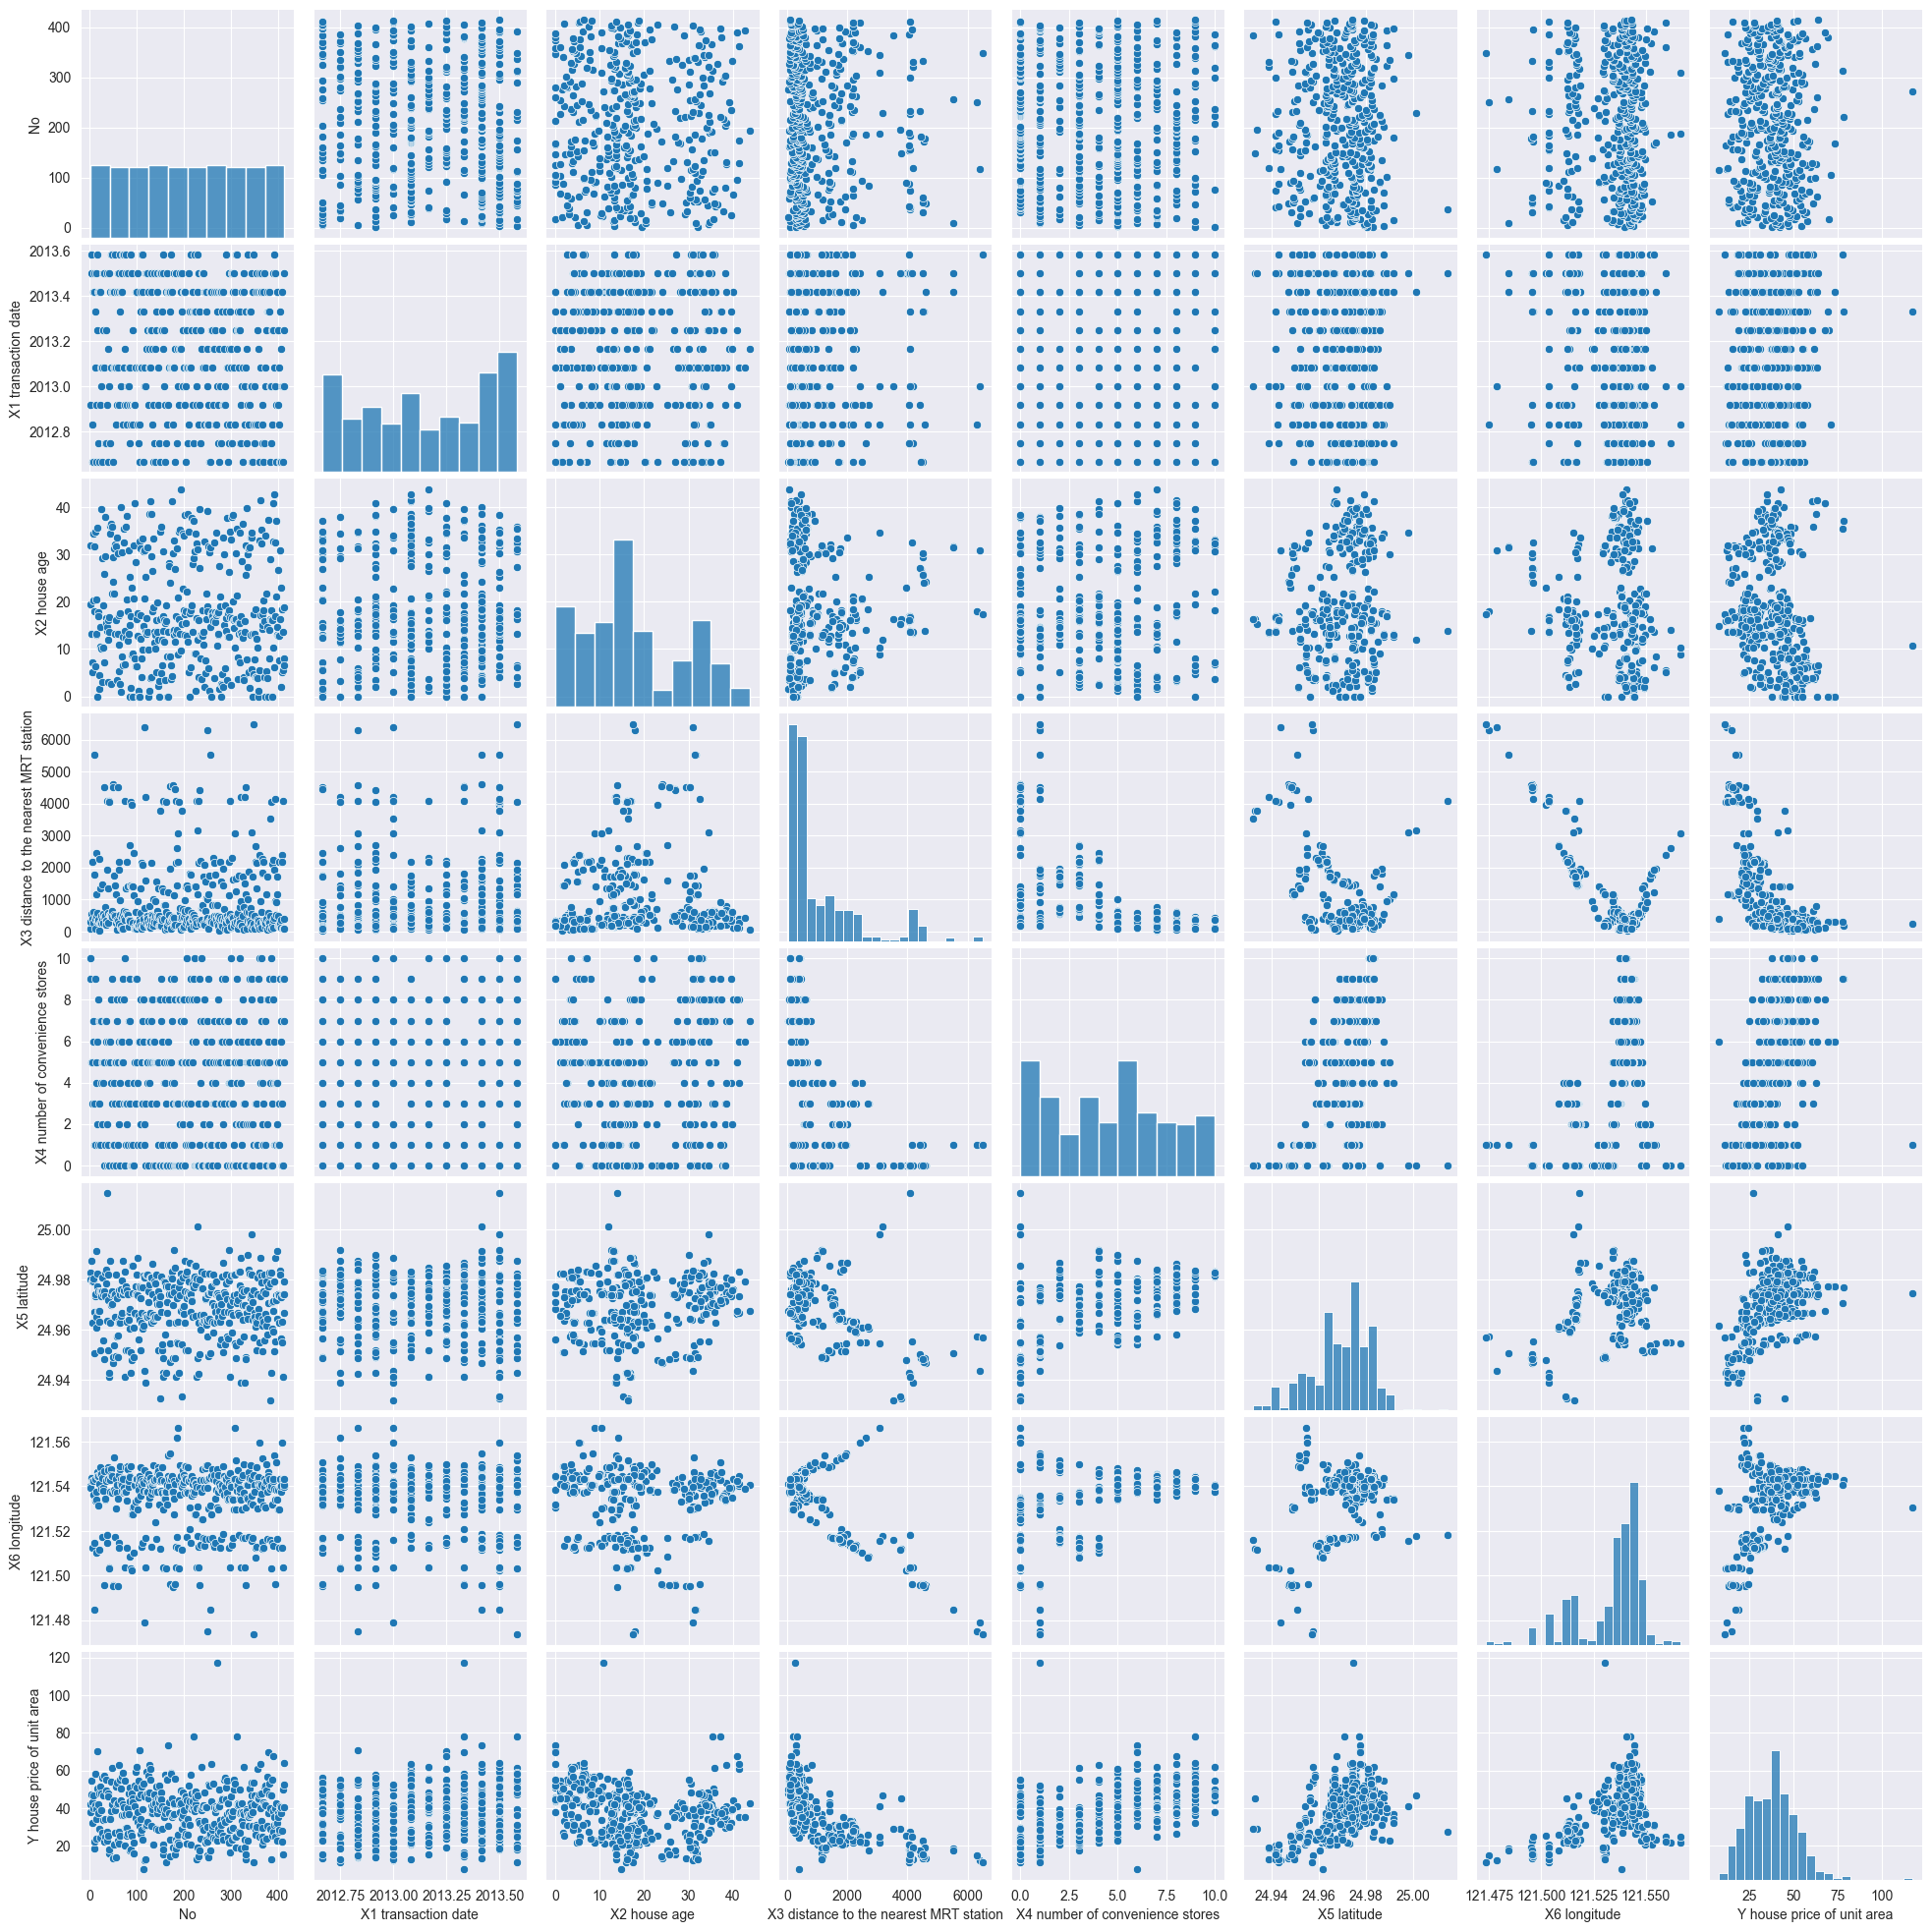

In [41]:
sns.pairplot(df_mult)

In [42]:
df_mult.corr()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
No,1.000000,-0.048658,-0.032808,-0.013573,-0.012699,-0.010110,-0.011059,-0.028587
X1 transaction date,-0.048658,1.000000,0.017549,0.060880,0.009635,0.035058,-0.041082,0.087491
X2 house age,-0.032808,0.017549,1.000000,0.025622,0.049593,0.054420,-0.048520,-0.210567
X3 distance to the nearest MRT station,-0.013573,0.060880,0.025622,1.000000,-0.602519,-0.591067,-0.806317,-0.673613
X4 number of convenience stores,-0.012699,0.009635,0.049593,-0.602519,1.000000,0.444143,0.449099,0.571005
X5 latitude,-0.010110,0.035058,0.054420,-0.591067,0.444143,1.000000,0.412924,0.546307
X6 longitude,-0.011059,-0.041082,-0.048520,-0.806317,0.449099,0.412924,1.000000,0.523287
Y house price of unit area,-0.028587,0.087491,-0.210567,-0.673613,0.571005,0.546307,0.523287,1.000000


In [43]:
X = df_mult.drop(columns=["Y house price of unit area","X1 transaction date","X2 house age","No"])

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [46]:
standscaler = StandardScaler()
X_train = standscaler.fit_transform(X_train)
X_test = standscaler.fit_transform(X_test)
linear_reg = LinearRegression()
linear_reg.fit(X_train, y_train)

LinearRegression()

In [47]:
y_pred = linear_reg.predict(X_test)

In [48]:
r2 = r2_score(y_test,y_pred)
r2

0.5988609844775663

In [50]:
mae = mean_absolute_error(y_test,y_pred)
mae

6.491929325831474

In [54]:
residuals = y_test-y_pred
df_residuals = pd.DataFrame({'Error Values': (residuals)})


In [55]:
df_residuals

,Error Values
358,1.131787
350,0.659809
373,11.504069
399,-3.570594
369,-9.723736
...,...
31,-21.649293
283,-14.183420
157,-6.880488
203,-0.184385


<Axes: ylabel='Count'>

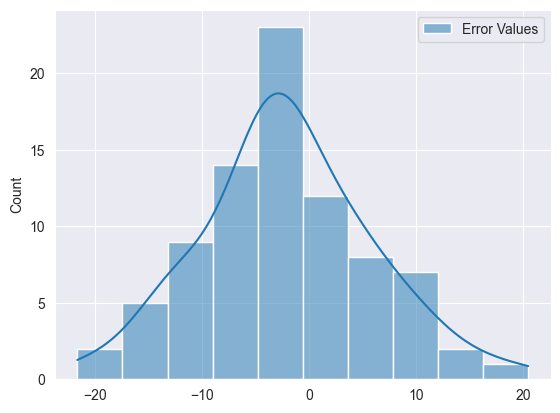

In [56]:
sns.histplot(df_residuals,kde=True)